# Ent-Agent-Bench — Results Analysis

Analyzes every model's benchmark results under `results/<model>/<model>.csv` — first model by model, then aggregated across the whole fleet. The aggregated section covers the core comparison this benchmark exists to make: **code-mode (Python/JS/TS) vs structured JSON/MCP tool-calling**.

Run the benchmark first (e.g. `./run_full_benchmark.sh`) so the CSVs exist, then run this notebook top to bottom.

In [62]:
import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (8, 4)

In [63]:
RESULTS_DIR = Path("../results")

csv_paths = sorted(RESULTS_DIR.glob("*/*.csv"))
if not csv_paths:
    raise FileNotFoundError(
        f"no CSVs found under {RESULTS_DIR.resolve()} -- run the benchmark first "
        "(e.g. ./run_full_benchmark.sh) so results/<model>/<model>.csv exist."
    )

df = pd.concat((pd.read_csv(p) for p in csv_paths), ignore_index=True)
df = df.dropna(how="all")  # guard against a stray blank trailing row

# A clean run is one that actually completed the episode loop -- infra/model-API/
# episode-level errors are harness or serving-setup problems (e.g. a request
# landing while the model was still loading), not a genuine task failure, and
# would otherwise silently drag a model's pass rate down for reasons that have
# nothing to do with its actual task-solving ability.
df["clean_run"] = ~(
    df["infra_error"].astype(bool)
    | df["model_api_error"].astype(bool)
    | df["episode_error"].astype(bool)
)
df["code_mode"] = df["surface"].isin(["python", "js", "ts"])

print(f"loaded {len(df)} episodes across {df['model'].nunique()} model(s): {sorted(df['model'].unique())}")
print(f"clean runs: {df['clean_run'].sum()} / {len(df)} ({df['clean_run'].mean():.1%})")

loaded 3360 episodes across 7 model(s): ['gemma4-12b-llamacpp-local', 'gemma4-26b-a4b-llamacpp-local', 'gemma4-31b-llamacpp-local', 'gpt-oss-20b-llamacpp-local', 'qwen2.5-14b-instruct-llamacpp-local', 'qwen2.5-72b-instruct-q8-llamacpp-local', 'qwen3-coder-30b-a3b-llamacpp-local']
clean runs: 3171 / 3360 (94.4%)


## Per-Model Analysis

For each model: pass rate by surface and by difficulty tier, error profile, and efficiency (turns, tool calls, tokens, latency). Episodes that hit a harness/infra-level error are called out and excluded from the pass-rate numbers below them, so a serving hiccup doesn't get counted as a task failure.

### gemma4-12b-llamacpp-local

*18 of 480 episodes hit an infra/model-API/episode-level error (harness or serving issue, not a task failure) -- excluded from the pass rates below.*

**Pass rate by surface**

,pass_rate,n
surface,,
python,0.949,118
js,0.740,104
ts,0.758,120
json_mcp,0.892,120


**Pass rate by difficulty**

,pass_rate,n
difficulty,,
easy,0.878,115
medium,0.898,108
hard,0.867,120
expert,0.714,119


**Efficiency by surface (means)**

,model_turns,tool_calls_made,total_tokens,total_latency_seconds
surface,,,,
python,4.297,4.941,21683.076,20.068
js,8.202,11.625,43090.481,51.309
ts,5.192,15.675,41385.458,99.476
json_mcp,5.850,5.175,16412.800,29.098


**Error profile (total counts across all episodes)**

tool_error_count        4
syntax_error_count      1
type_error_count       15
runtime_error_count    58
parse_error_count       0
Name: total, dtype: int64

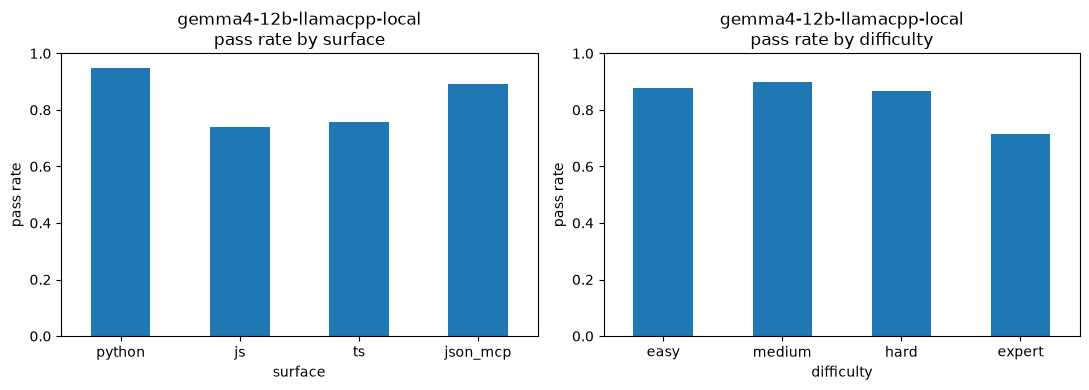

### gemma4-26b-a4b-llamacpp-local

*3 of 480 episodes hit an infra/model-API/episode-level error (harness or serving issue, not a task failure) -- excluded from the pass rates below.*

**Pass rate by surface**

,pass_rate,n
surface,,
python,0.932,117
js,0.917,120
ts,0.925,120
json_mcp,0.933,120


**Pass rate by difficulty**

,pass_rate,n
difficulty,,
easy,1.000,117
medium,0.983,120
hard,0.958,120
expert,0.767,120


**Efficiency by surface (means)**

,model_turns,tool_calls_made,total_tokens,total_latency_seconds
surface,,,,
python,4.581,5.085,22970.179,9.237
js,6.975,11.342,35955.158,13.739
ts,5.633,6.358,37007.658,10.551
json_mcp,5.617,4.892,14718.800,10.002


**Error profile (total counts across all episodes)**

tool_error_count        0
syntax_error_count      1
type_error_count        5
runtime_error_count    39
parse_error_count       0
Name: total, dtype: int64

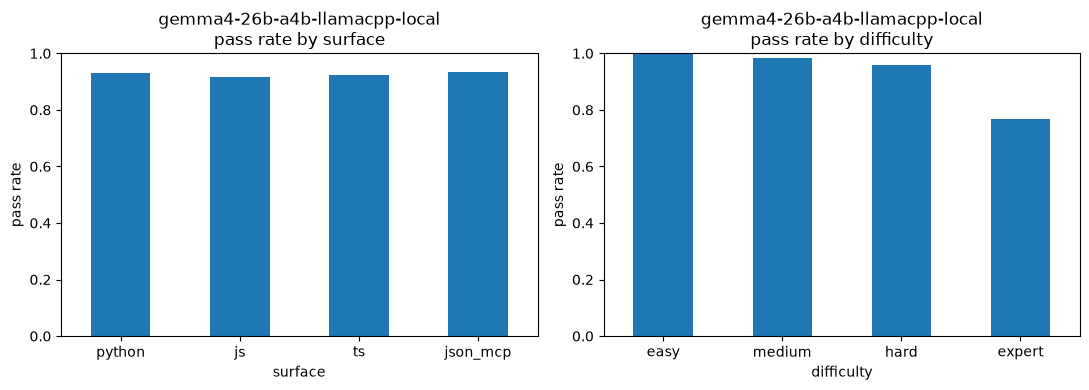

### gemma4-31b-llamacpp-local

*5 of 480 episodes hit an infra/model-API/episode-level error (harness or serving issue, not a task failure) -- excluded from the pass rates below.*

**Pass rate by surface**

,pass_rate,n
surface,,
python,0.930,115
js,0.892,120
ts,0.908,120
json_mcp,0.933,120


**Pass rate by difficulty**

,pass_rate,n
difficulty,,
easy,0.974,116
medium,1.000,120
hard,0.942,120
expert,0.748,119


**Efficiency by surface (means)**

,model_turns,tool_calls_made,total_tokens,total_latency_seconds
surface,,,,
python,4.722,5.052,22477.965,93.660
js,6.283,8.217,31823.200,71.787
ts,3.908,6.442,24804.600,44.560
json_mcp,4.767,5.000,11411.058,35.877


**Error profile (total counts across all episodes)**

tool_error_count        0
syntax_error_count      0
type_error_count        6
runtime_error_count    43
parse_error_count       0
Name: total, dtype: int64

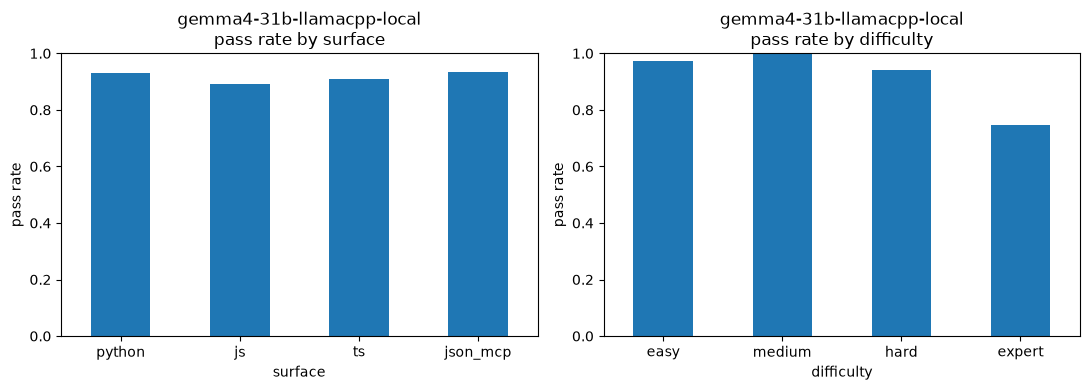

### gpt-oss-20b-llamacpp-local

*79 of 480 episodes hit an infra/model-API/episode-level error (harness or serving issue, not a task failure) -- excluded from the pass rates below.*

**Pass rate by surface**

,pass_rate,n
surface,,
python,0.815,108
js,0.625,104
ts,0.809,115
json_mcp,0.851,74


**Pass rate by difficulty**

,pass_rate,n
difficulty,,
easy,0.926,94
medium,0.677,96
hard,0.788,104
expert,0.701,107


**Efficiency by surface (means)**

,model_turns,tool_calls_made,total_tokens,total_latency_seconds
surface,,,,
python,4.093,7.722,19434.556,6.455
js,8.558,13.413,49383.587,14.340
ts,4.270,10.035,28043.826,8.896
json_mcp,6.581,5.608,13596.459,6.377


**Error profile (total counts across all episodes)**

tool_error_count         4
syntax_error_count      11
type_error_count        81
runtime_error_count    275
parse_error_count        0
Name: total, dtype: int64

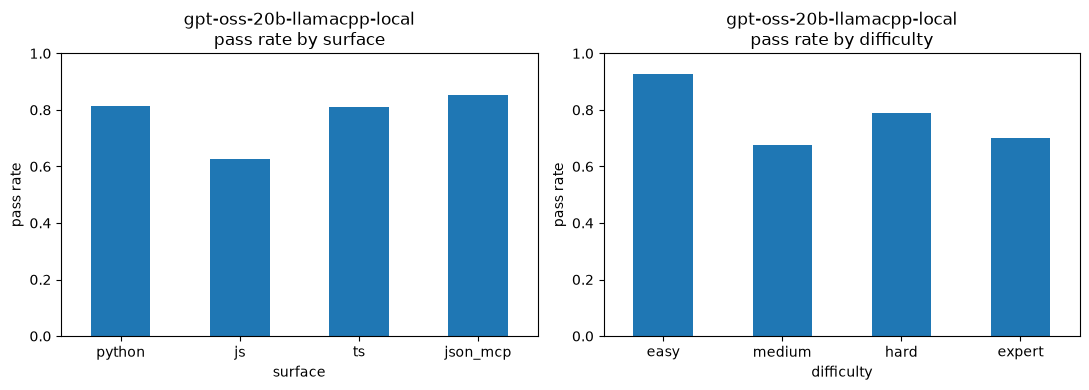

### qwen2.5-14b-instruct-llamacpp-local

*53 of 480 episodes hit an infra/model-API/episode-level error (harness or serving issue, not a task failure) -- excluded from the pass rates below.*

**Pass rate by surface**

,pass_rate,n
surface,,
python,0.298,114
js,0.148,88
ts,0.193,109
json_mcp,0.319,116


**Pass rate by difficulty**

,pass_rate,n
difficulty,,
easy,0.243,103
medium,0.209,110
hard,0.320,103
expert,0.216,111


**Efficiency by surface (means)**

,model_turns,tool_calls_made,total_tokens,total_latency_seconds
surface,,,,
python,5.649,7.579,31835.149,29.411
js,8.682,9.875,57473.818,54.573
ts,12.881,4.000,109788.229,105.669
json_mcp,3.284,14.802,9825.612,12.328


**Error profile (total counts across all episodes)**

tool_error_count       1351
syntax_error_count     1145
type_error_count        121
runtime_error_count     533
parse_error_count         0
Name: total, dtype: int64

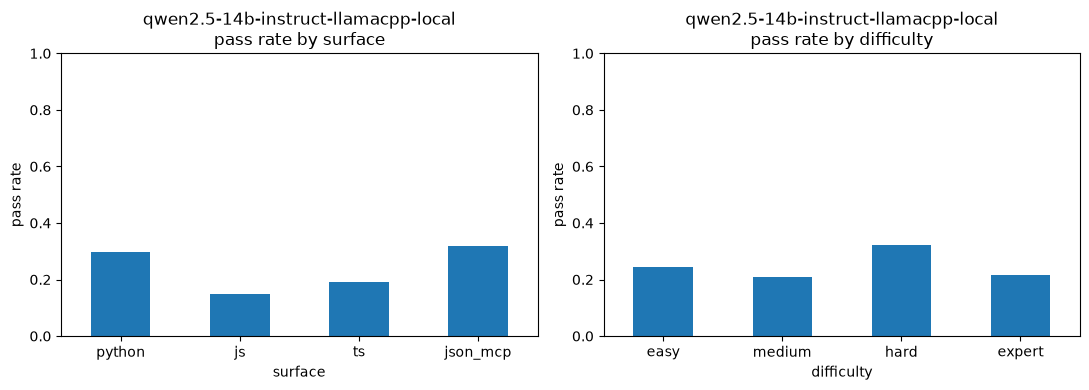

### qwen2.5-72b-instruct-q8-llamacpp-local

*6 of 480 episodes hit an infra/model-API/episode-level error (harness or serving issue, not a task failure) -- excluded from the pass rates below.*

**Pass rate by surface**

,pass_rate,n
surface,,
python,0.414,116
js,0.339,118
ts,0.475,120
json_mcp,0.825,120


**Pass rate by difficulty**

,pass_rate,n
difficulty,,
easy,0.513,115
medium,0.513,119
hard,0.567,120
expert,0.467,120


**Efficiency by surface (means)**

,model_turns,tool_calls_made,total_tokens,total_latency_seconds
surface,,,,
python,4.448,8.819,21618.103,54.908
js,4.763,5.102,32771.093,93.834
ts,4.783,4.525,37192.108,89.891
json_mcp,5.908,5.808,18059.550,17.118


**Error profile (total counts across all episodes)**

tool_error_count        84
syntax_error_count     144
type_error_count       125
runtime_error_count    429
parse_error_count        0
Name: total, dtype: int64

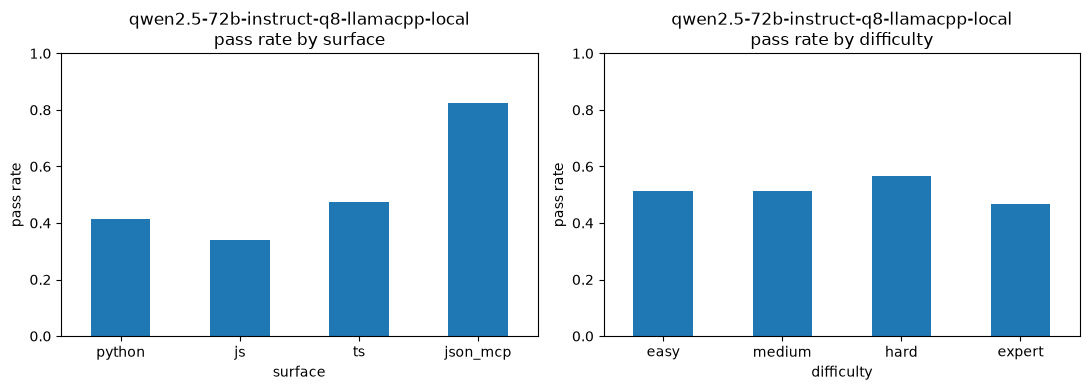

### qwen3-coder-30b-a3b-llamacpp-local

*25 of 480 episodes hit an infra/model-API/episode-level error (harness or serving issue, not a task failure) -- excluded from the pass rates below.*

**Pass rate by surface**

,pass_rate,n
surface,,
python,0.838,117
js,0.806,98
ts,0.742,120
json_mcp,0.808,120


**Pass rate by difficulty**

,pass_rate,n
difficulty,,
easy,0.844,109
medium,0.802,111
hard,0.846,117
expert,0.703,118


**Efficiency by surface (means)**

,model_turns,tool_calls_made,total_tokens,total_latency_seconds
surface,,,,
python,5.632,7.085,28119.171,6.810
js,7.163,8.153,36783.663,8.090
ts,8.108,16.350,54923.150,12.296
json_mcp,8.133,6.350,32178.542,6.252


**Error profile (total counts across all episodes)**

tool_error_count       21
syntax_error_count      2
type_error_count       82
runtime_error_count    76
parse_error_count       0
Name: total, dtype: int64

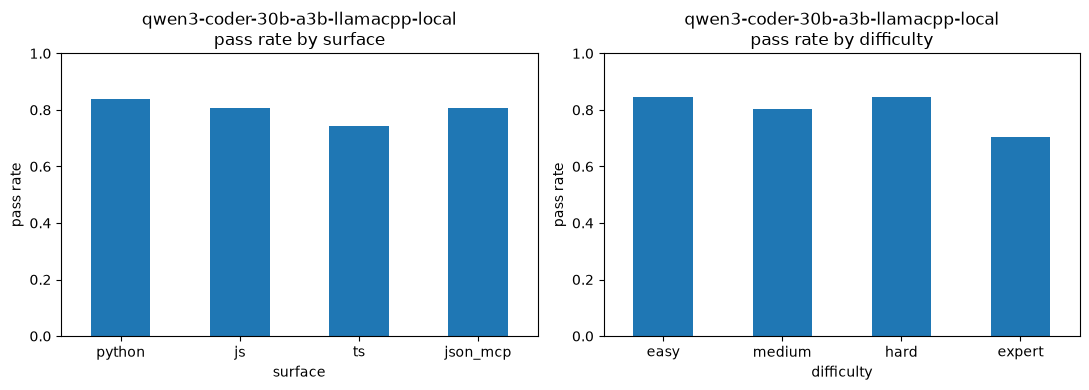

In [64]:
SURFACE_ORDER = ["python", "js", "ts", "json_mcp"]
DIFFICULTY_ORDER = ["easy", "medium", "hard", "expert"]

for model in sorted(df["model"].unique()):
    display(Markdown(f"### {model}"))
    sub = df[df["model"] == model]
    clean = sub[sub["clean_run"]]

    n_dirty = len(sub) - len(clean)
    if n_dirty:
        display(Markdown(
            f"*{n_dirty} of {len(sub)} episodes hit an infra/model-API/episode-level "
            f"error (harness or serving issue, not a task failure) -- excluded from "
            f"the pass rates below.*"
        ))

    display(Markdown("**Pass rate by surface**"))
    display(clean.groupby("surface")["passed"].agg(["mean", "count"])
            .rename(columns={"mean": "pass_rate", "count": "n"})
            .reindex(SURFACE_ORDER))

    display(Markdown("**Pass rate by difficulty**"))
    display(clean.groupby("difficulty")["passed"].agg(["mean", "count"])
            .rename(columns={"mean": "pass_rate", "count": "n"})
            .reindex(DIFFICULTY_ORDER))

    display(Markdown("**Efficiency by surface (means)**"))
    display(clean.groupby("surface")[
        ["model_turns", "tool_calls_made", "total_tokens", "total_latency_seconds"]
    ].mean().reindex(SURFACE_ORDER))

    error_cols = ["tool_error_count", "syntax_error_count", "type_error_count",
                  "runtime_error_count", "parse_error_count"]
    display(Markdown("**Error profile (total counts across all episodes)**"))
    display(clean[error_cols].sum().rename("total"))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    clean.groupby("surface")["passed"].mean().reindex(SURFACE_ORDER).plot.bar(
        ax=axes[0], title=f"{model}\npass rate by surface", ylim=(0, 1))
    clean.groupby("difficulty")["passed"].mean().reindex(DIFFICULTY_ORDER).plot.bar(
        ax=axes[1], title=f"{model}\npass rate by difficulty", ylim=(0, 1))
    for ax in axes:
        ax.set_ylabel("pass rate")
        ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

## Aggregated Cross-Model Analysis

### Overall pass rate by model

,pass_rate,n
model,,
gemma4-26b-a4b-llamacpp-local,0.927,477
gemma4-31b-llamacpp-local,0.916,475
gemma4-12b-llamacpp-local,0.838,462
qwen3-coder-30b-a3b-llamacpp-local,0.798,455
gpt-oss-20b-llamacpp-local,0.771,401
qwen2.5-72b-instruct-q8-llamacpp-local,0.515,474
qwen2.5-14b-instruct-llamacpp-local,0.246,427


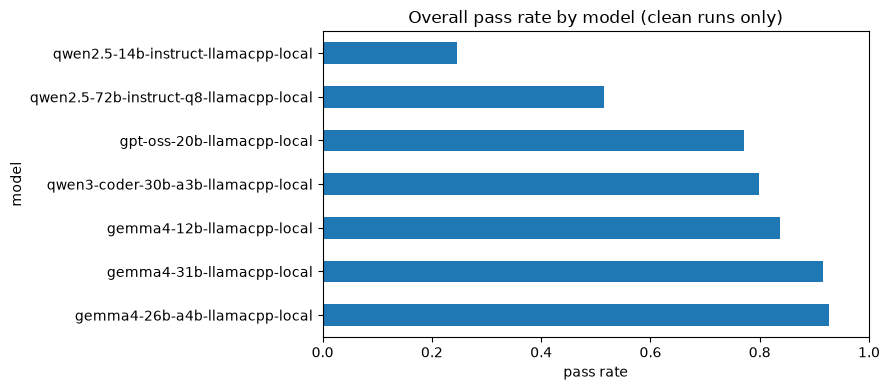

In [65]:
clean = df[df["clean_run"]]

overall = (clean.groupby("model")["passed"].agg(["mean", "count"])
           .rename(columns={"mean": "pass_rate", "count": "n"})
           .sort_values("pass_rate", ascending=False))
display(overall)

fig, ax = plt.subplots(figsize=(9, 4))
overall["pass_rate"].plot.barh(ax=ax)
ax.set_xlabel("pass rate")
ax.set_xlim(0, 1)
ax.set_title("Overall pass rate by model (clean runs only)")
plt.tight_layout()
plt.show()

### The core question: code-mode vs json_mcp

Every task ran through both styles: writing code (`python`/`js`/`ts`) versus emitting structured JSON/MCP tool calls. This is the comparison the whole benchmark exists to make.

code_mode,json_mcp,code_mode (py/js/ts avg)
model,,
gemma4-12b-llamacpp-local,0.892,0.819
gemma4-26b-a4b-llamacpp-local,0.933,0.924
gemma4-31b-llamacpp-local,0.933,0.910
gpt-oss-20b-llamacpp-local,0.851,0.752
qwen2.5-14b-instruct-llamacpp-local,0.319,0.219
qwen2.5-72b-instruct-q8-llamacpp-local,0.825,0.410
qwen3-coder-30b-a3b-llamacpp-local,0.808,0.794


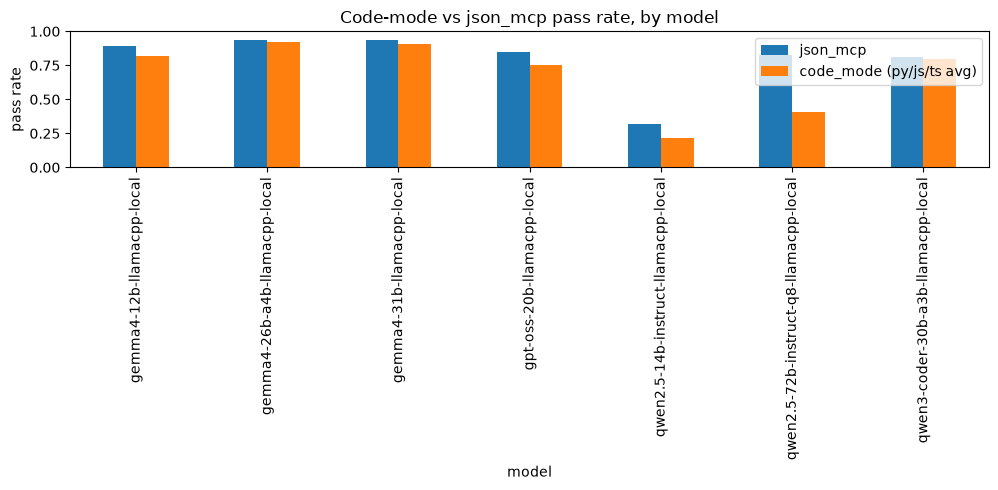

In [66]:
code_vs_structured = (
    clean.groupby(["model", "code_mode"])["passed"]
    .mean()
    .unstack()
    .rename(columns={True: "code_mode (py/js/ts avg)", False: "json_mcp"})
)
display(code_vs_structured)

ax = code_vs_structured.plot.bar(figsize=(10, 5))
ax.set_ylabel("pass rate")
ax.set_ylim(0, 1)
ax.set_title("Code-mode vs json_mcp pass rate, by model")
ax.legend(title="")
plt.tight_layout()
plt.show()

### Code-mode vs json_mcp, by model AND difficulty tier

Does the gap narrow (or reverse) on harder tiers, where code-mode's ability to batch several tool calls into one `execute()` turn should matter most? One grid cell per model: difficulty tier on the x-axis, code-mode vs json_mcp pass rate side by side.

In [67]:
tier_pivot = (
    clean.groupby(["model", "difficulty", "code_mode"])["passed"]
    .mean()
    .unstack("code_mode")
    .rename(columns={True: "code_mode", False: "json_mcp"})
    .reindex(DIFFICULTY_ORDER, level="difficulty")
)
display(tier_pivot)

code_mode                                          json_mcp  code_mode
model                                  difficulty                     
gemma4-12b-llamacpp-local              easy           0.900      0.871
                                       medium         0.967      0.872
                                       hard           0.967      0.833
                                       expert         0.733      0.708
gemma4-26b-a4b-llamacpp-local          easy           1.000      1.000
                                       medium         1.000      0.978
                                       hard           0.967      0.956
                                       expert         0.767      0.767
gemma4-31b-llamacpp-local              easy           1.000      0.965
                                       medium         1.000      1.000
                                       hard           0.967      0.933
                                       expert         0.767      0.742
gpt-oss-20b-llamacpp-local             easy           1.000      0.912
                                       medium         0.938      0.625
                                       hard           0.950      0.750
                                       expert         0.625      0.723
qwen2.5-14b-instruct-llamacpp-local    easy           0.308      0.221
                                       medium         0.100      0.250
                                       hard           0.433      0.274
                                       expert         0.433      0.136
qwen2.5-72b-instruct-q8-llamacpp-local easy           0.800      0.412
                                       medium         0.800      0.416
                                       hard           0.933      0.444
                                       expert         0.767      0.367
qwen3-coder-30b-a3b-llamacpp-local     easy           0.800      0.861
                                       medium         0.867      0.778
                                       hard           0.833      0.851
                                       expert         0.733      0.693

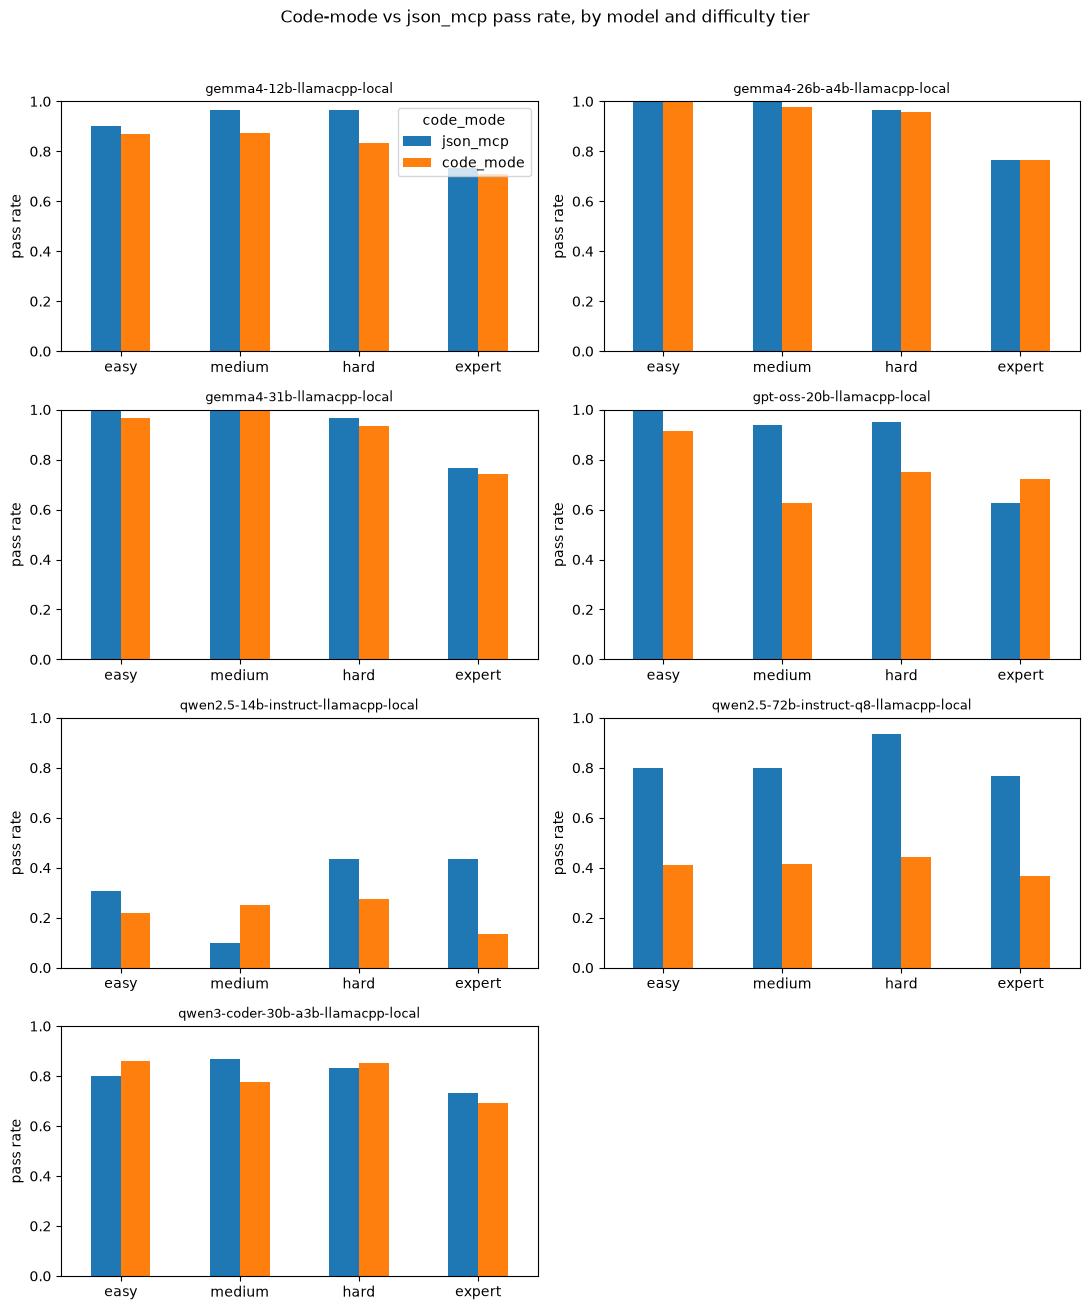

In [68]:
models_sorted = sorted(clean["model"].unique())
n = len(models_sorted)
ncols = 2
nrows = -(-n // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows), squeeze=False)

for ax, model in zip(axes.flat, models_sorted):
    sub = (tier_pivot.loc[model].reindex(DIFFICULTY_ORDER)
           if model in tier_pivot.index.get_level_values("model") else None)
    if sub is None or sub.empty:
        ax.axis("off")
        continue
    sub.plot.bar(ax=ax, ylim=(0, 1), legend=(ax is axes.flat[0]))
    ax.set_title(model, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("pass rate")
    ax.tick_params(axis="x", rotation=0)

# hide any unused subplot slots when the model count doesn't fill the grid
for ax in axes.flat[n:]:
    ax.axis("off")

fig.suptitle("Code-mode vs json_mcp pass rate, by model and difficulty tier", y=1.02)
plt.tight_layout()
plt.show()

### Where does code-mode's batching advantage actually show up?

Pass rate isn't the only lens -- **turn count** is where batching should show up most directly, since code-mode can loop over several tool calls in one `execute()` turn while json_mcp needs one turn per call.

code_mode,json_mcp,code_mode
difficulty,,
easy,5.247,6.280
medium,5.867,6.337
hard,4.975,5.316
expert,6.662,6.305


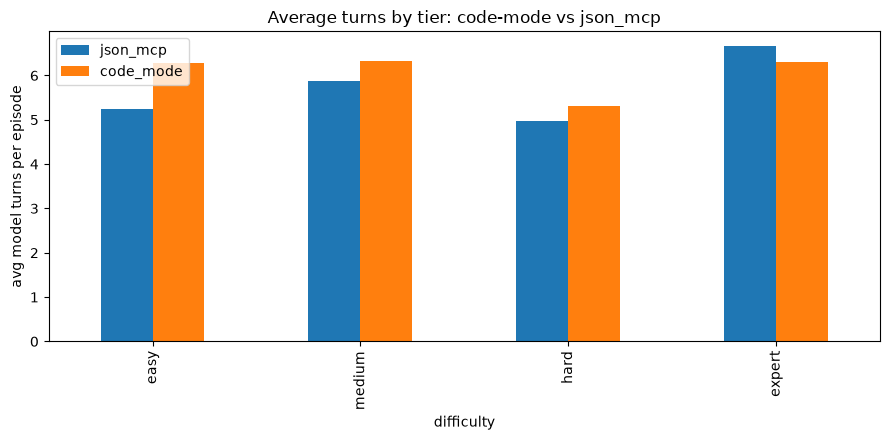

In [69]:
turns_by_tier = (
    clean.groupby(["difficulty", "code_mode"])["model_turns"]
    .mean()
    .unstack("code_mode")
    .rename(columns={True: "code_mode", False: "json_mcp"})
    .reindex(DIFFICULTY_ORDER)
)
display(turns_by_tier)

ax = turns_by_tier.plot.bar(figsize=(9, 4.5))
ax.set_ylabel("avg model turns per episode")
ax.set_title("Average turns by tier: code-mode vs json_mcp")
ax.legend(title="")
plt.tight_layout()
plt.show()

### Does the tier effect actually come from task pattern, not difficulty?

The difficulty tier and the task's underlying *pattern* are confounded in this corpus by construction: the only two templates that require acting on a runtime-discovered **set** of records (`update_every_matching_deal`, `triage_each_followup`) exist exclusively at the `expert` tier -- every `easy`/`medium`/`hard` template is a single-record lookup-and-act, a single-query aggregate, or a dependent multi-hop chain, none of which give code-mode anything to batch. So "the code-mode gap narrows at expert" (seen above) could really mean "the gap narrows on iterate-over-a-set tasks", with tier just riding along as a correlated label.

Each frozen task's `template` field (and a coarser `pattern` bucketing) lets us check this directly -- including a clean natural control: all four `expert`-tier templates share the same nominal difficulty, but only two of them are actually iterative, so comparing template-by-template *within* `expert` isolates pattern while holding tier fixed.

In [70]:
FROZEN_DIR = Path("../src/db/scenarios/crm_scenario/tasks/frozen")

# `pattern` is a first-class field on every frozen task (set in build_tasks.py
# from each template YAML's own `pattern:` key) -- not a notebook-side guess,
# so it can't drift out of sync with the corpus the way a hand-maintained
# lookup table would.
task_meta = []
for p in FROZEN_DIR.glob("*/*.json"):
    d = json.loads(p.read_text())
    task_meta.append({"difficulty": d["difficulty"], "task_id": d["task_id"],
                       "template": d["template"], "pattern": d["pattern"]})
task_meta = pd.DataFrame(task_meta).drop_duplicates(subset=["difficulty", "task_id"])

clean = clean.merge(task_meta, on=["difficulty", "task_id"], how="left", validate="many_to_one")
assert clean["template"].notna().all(), "some episodes didn't match a frozen task"

print(f"templates per tier:")
display(task_meta.groupby("difficulty")["template"].unique())

templates per tier:


difficulty
easy      [act_on_a_deal, sum_pipeline_by_reps, count_op...
expert    [update_every_matching_deal, decide_by_deal_va...
hard       [act_on_a_contact, act_on_a_deal, act_on_a_lead]
medium    [sum_pipeline_with_distractor, act_on_a_follow...
Name: template, dtype: object

code_mode,json_mcp,code_mode
pattern,,
single_record_act,0.838,0.728
single_query_aggregate,0.800,0.747
dependent_chain,0.833,0.762
conditional_branch,0.917,0.732
iterate_over_set,0.576,0.512
parallel_independent,0.813,0.737


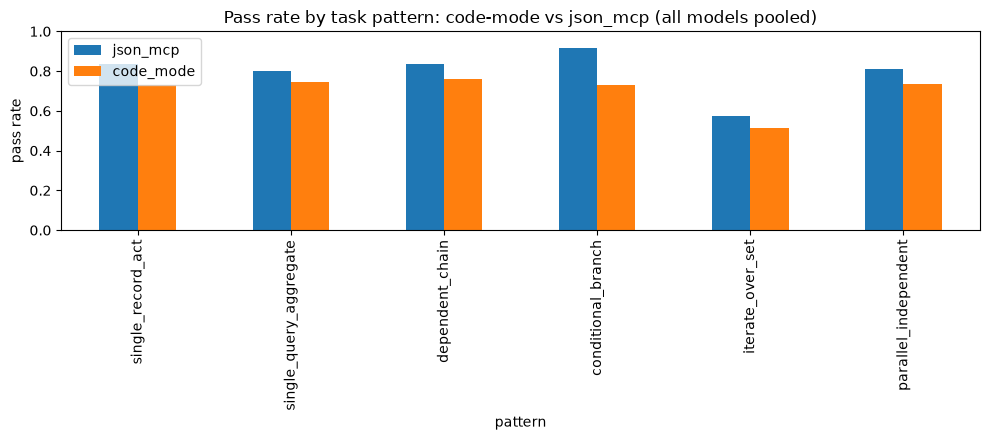

In [71]:
PATTERN_ORDER = ["single_record_act", "single_query_aggregate", "dependent_chain",
                  "conditional_branch", "iterate_over_set", "parallel_independent"]

pattern_pivot = (
    clean.groupby(["pattern", "code_mode"])["passed"]
    .mean()
    .unstack("code_mode")
    .rename(columns={True: "code_mode", False: "json_mcp"})
    .reindex(PATTERN_ORDER)
)
display(pattern_pivot)

ax = pattern_pivot.plot.bar(figsize=(10, 4.5))
ax.set_ylabel("pass rate")
ax.set_ylim(0, 1)
ax.set_title("Pass rate by task pattern: code-mode vs json_mcp (all models pooled)")
ax.legend(title="")
plt.tight_layout()
plt.show()

code_mode,json_mcp,code_mode
pattern,,
single_record_act,5.174,5.800
single_query_aggregate,6.140,6.968
dependent_chain,4.667,5.881
conditional_branch,5.700,6.377
iterate_over_set,7.280,6.317
parallel_independent,5.675,6.127


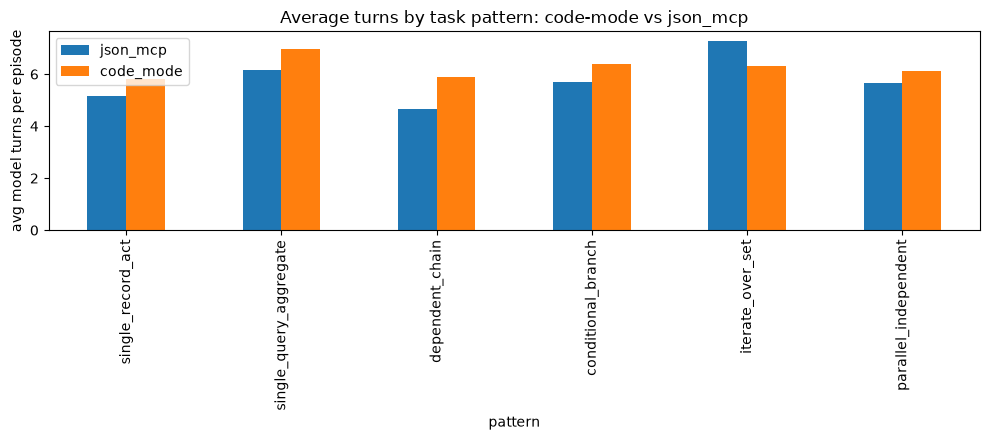

In [72]:
turns_by_pattern = (
    clean.groupby(["pattern", "code_mode"])["model_turns"]
    .mean()
    .unstack("code_mode")
    .rename(columns={True: "code_mode", False: "json_mcp"})
    .reindex(PATTERN_ORDER)
)
display(turns_by_pattern)

ax = turns_by_pattern.plot.bar(figsize=(10, 4.5))
ax.set_ylabel("avg model turns per episode")
ax.set_title("Average turns by task pattern: code-mode vs json_mcp")
ax.legend(title="")
plt.tight_layout()
plt.show()

### The natural control: template-by-template within `expert` only

All four `expert` templates share the same difficulty label, so this holds tier fixed and varies only the pattern -- the cleanest read on whether batching itself (not "harder tasks" in general) is what helps.

code_mode,json_mcp,code_mode
template,,
decide_by_deal_value,0.917,0.732
find_deal_via_chain,0.833,0.762
update_every_matching_deal,0.916,0.783
triage_each_followup,0.000,0.015


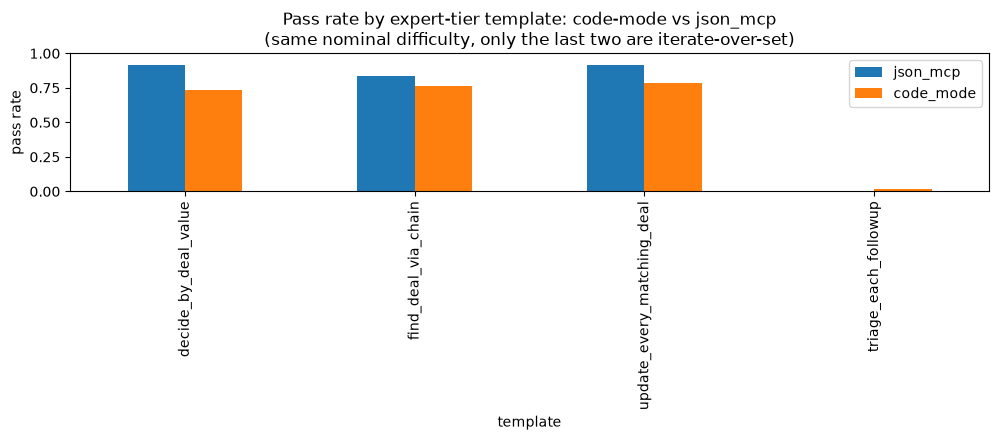

In [73]:
expert_only = clean[clean["difficulty"] == "expert"]
EXPERT_TEMPLATE_ORDER = ["decide_by_deal_value", "find_deal_via_chain",
                          "update_every_matching_deal", "triage_each_followup"]

expert_template_pivot = (
    expert_only.groupby(["template", "code_mode"])["passed"]
    .mean()
    .unstack("code_mode")
    .rename(columns={True: "code_mode", False: "json_mcp"})
    .reindex(EXPERT_TEMPLATE_ORDER)
)
display(expert_template_pivot)

ax = expert_template_pivot.plot.bar(figsize=(10, 4.5))
ax.set_ylabel("pass rate")
ax.set_ylim(0, 1)
ax.set_title("Pass rate by expert-tier template: code-mode vs json_mcp\n(same nominal difficulty, only the last two are iterate-over-set)")
ax.legend(title="")
plt.tight_layout()
plt.show()

### Pass rate by model and surface (all four surfaces individually)

surface,python,js,ts,json_mcp
model,,,,
gemma4-12b-llamacpp-local,0.949,0.740,0.758,0.892
gemma4-26b-a4b-llamacpp-local,0.932,0.917,0.925,0.933
gemma4-31b-llamacpp-local,0.930,0.892,0.908,0.933
gpt-oss-20b-llamacpp-local,0.815,0.625,0.809,0.851
qwen2.5-14b-instruct-llamacpp-local,0.298,0.148,0.193,0.319
qwen2.5-72b-instruct-q8-llamacpp-local,0.414,0.339,0.475,0.825
qwen3-coder-30b-a3b-llamacpp-local,0.838,0.806,0.742,0.808


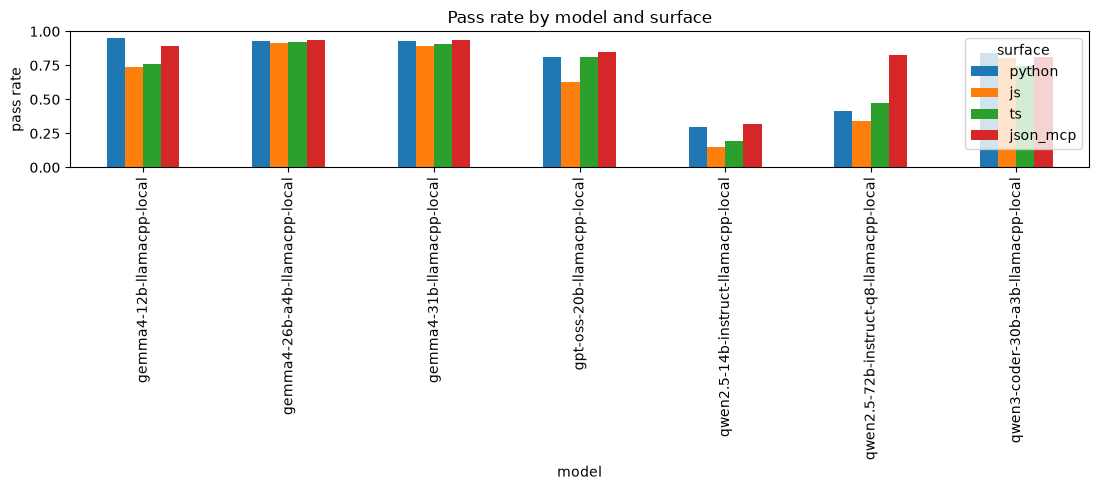

In [74]:
by_surface = (clean.groupby(["model", "surface"])["passed"].mean()
              .unstack().reindex(columns=SURFACE_ORDER))
display(by_surface)

ax = by_surface.plot.bar(figsize=(11, 5))
ax.set_ylabel("pass rate")
ax.set_ylim(0, 1)
ax.set_title("Pass rate by model and surface")
plt.tight_layout()
plt.show()

### Efficiency comparison

,model_turns,tool_calls_made,total_tokens,total_latency_seconds
model,,,,
gemma4-31b-llamacpp-local,4.922,6.189,22630.798,61.132
qwen2.5-72b-instruct-q8-llamacpp-local,4.981,6.044,27436.473,63.888
gemma4-26b-a4b-llamacpp-local,5.709,6.931,27692.463,10.893
gpt-oss-20b-llamacpp-local,5.761,9.471,28593.524,9.186
gemma4-12b-llamacpp-local,5.812,9.294,30250.658,50.071
qwen3-coder-30b-a3b-llamacpp-local,7.275,9.565,38125.154,8.385
qwen2.5-14b-instruct-llamacpp-local,7.478,9.101,51038.855,49.422


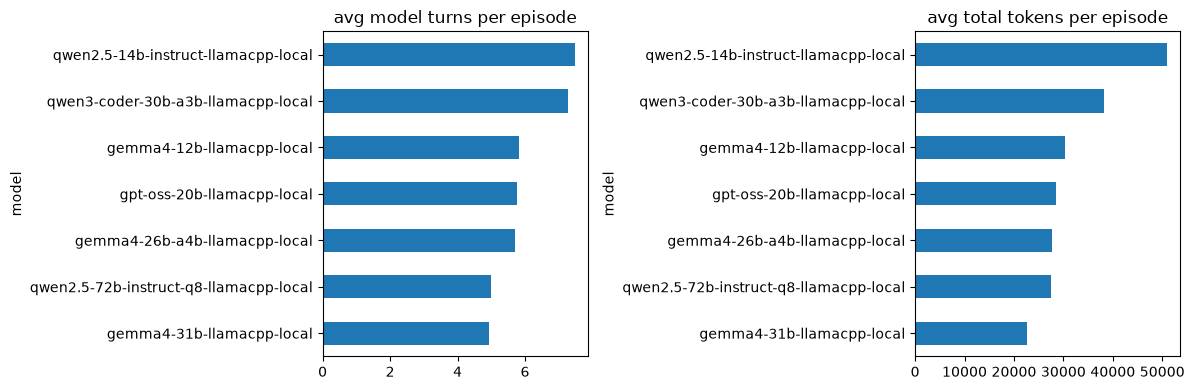

In [75]:
efficiency = (clean.groupby("model")[
    ["model_turns", "tool_calls_made", "total_tokens", "total_latency_seconds"]
].mean().sort_values("total_tokens"))
display(efficiency)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
efficiency["model_turns"].plot.barh(ax=axes[0], title="avg model turns per episode")
efficiency["total_tokens"].plot.barh(ax=axes[1], title="avg total tokens per episode")
plt.tight_layout()
plt.show()

### Error profile across models

,tool_error_count,syntax_error_count,type_error_count,runtime_error_count,parse_error_count
model,,,,,
gemma4-12b-llamacpp-local,4,1,15,58,0
gemma4-26b-a4b-llamacpp-local,0,1,5,39,0
gemma4-31b-llamacpp-local,0,0,6,43,0
gpt-oss-20b-llamacpp-local,4,11,81,275,0
qwen2.5-14b-instruct-llamacpp-local,1351,1145,121,533,0
qwen2.5-72b-instruct-q8-llamacpp-local,84,144,125,429,0
qwen3-coder-30b-a3b-llamacpp-local,21,2,82,76,0


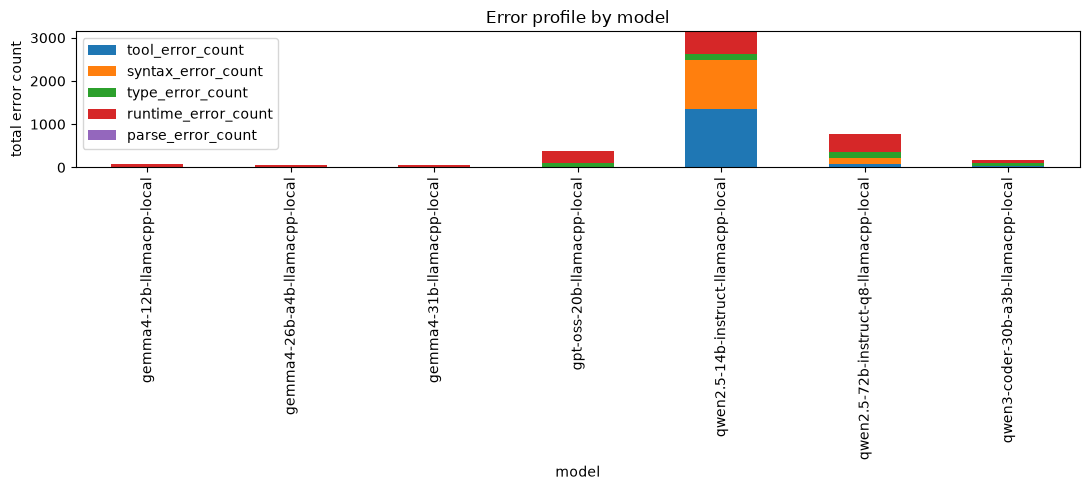

In [76]:
error_cols = ["tool_error_count", "syntax_error_count", "type_error_count",
              "runtime_error_count", "parse_error_count"]
error_profile = clean.groupby("model")[error_cols].sum()
display(error_profile)

ax = error_profile.plot.bar(stacked=True, figsize=(11, 5))
ax.set_ylabel("total error count")
ax.set_title("Error profile by model")
plt.tight_layout()
plt.show()

### Recovery rate

Among episodes that hit at least one error, how often the model still went on to pass the task anyway -- evidence the error-feedback loop (showing the model its own mistake and letting it try again) is actually working, not just padding the turn count.

In [77]:
had_error = clean[error_cols].sum(axis=1) > 0
recovery = (clean[had_error].groupby("model")["recovered"].mean()
            .rename("recovery_rate_given_error").to_frame())
display(recovery)

,recovery_rate_given_error
model,
gemma4-12b-llamacpp-local,0.661
gemma4-26b-a4b-llamacpp-local,0.854
gemma4-31b-llamacpp-local,0.868
gpt-oss-20b-llamacpp-local,0.646
qwen2.5-14b-instruct-llamacpp-local,0.187
qwen2.5-72b-instruct-q8-llamacpp-local,0.411
qwen3-coder-30b-a3b-llamacpp-local,0.613


### Harness/infra reliability by model

How often each model's episodes hit a harness-level error (Docker infra, model API, or an unexpected episode-level exception) rather than a genuine task outcome -- this is about the *serving setup*, not the model's own task-solving ability. Computed over every episode (not just clean_run), since this is exactly what clean_run excludes elsewhere in this notebook.

,infra_error,model_api_error,episode_error
model,,,
gemma4-12b-llamacpp-local,0.0,0.004,0.033
gemma4-26b-a4b-llamacpp-local,0.0,0.006,0.000
gemma4-31b-llamacpp-local,0.0,0.008,0.002
gpt-oss-20b-llamacpp-local,0.0,0.144,0.021
qwen2.5-14b-instruct-llamacpp-local,0.0,0.060,0.050
qwen2.5-72b-instruct-q8-llamacpp-local,0.0,0.010,0.002
qwen3-coder-30b-a3b-llamacpp-local,0.0,0.006,0.046


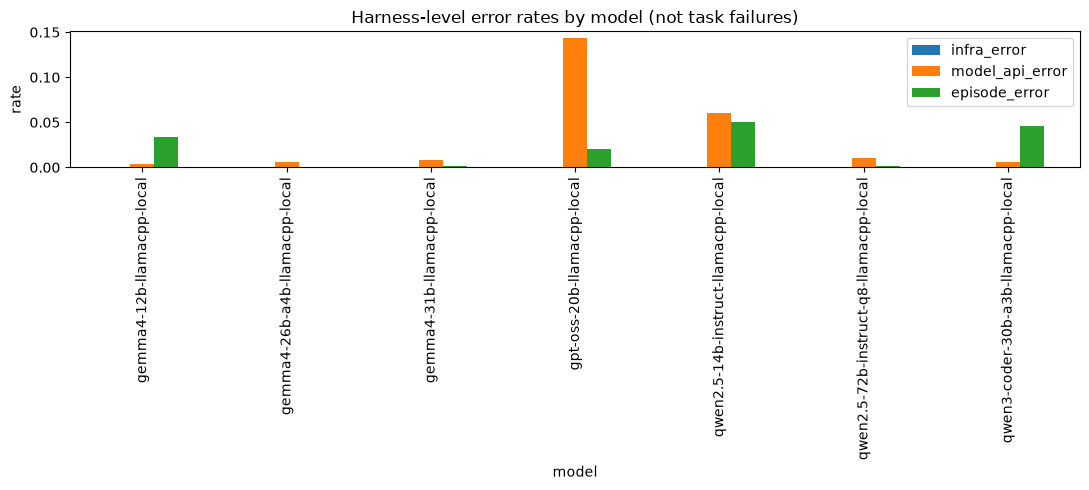

In [78]:
reliability = df.groupby("model")[["infra_error", "model_api_error", "episode_error"]].mean()
display(reliability)

ax = reliability.plot.bar(figsize=(11, 5))
ax.set_ylabel("rate")
ax.set_title("Harness-level error rates by model (not task failures)")
plt.tight_layout()
plt.show()

## Summary table

One row per model, the headline numbers from everything above, sorted by overall pass rate. Also saved to `summary_by_model.csv` alongside this notebook.

In [79]:
summary = pd.DataFrame({
    "overall_pass_rate": overall["pass_rate"],
    "code_mode_pass_rate": code_vs_structured["code_mode (py/js/ts avg)"],
    "json_mcp_pass_rate": code_vs_structured["json_mcp"],
    "avg_turns": efficiency["model_turns"],
    "avg_total_tokens": efficiency["total_tokens"],
    "harness_error_rate": reliability.sum(axis=1),
}).sort_values("overall_pass_rate", ascending=False)
display(summary)

summary.to_csv("summary_by_model.csv")
print("saved to analysis/summary_by_model.csv")

,overall_pass_rate,code_mode_pass_rate,json_mcp_pass_rate,avg_turns,avg_total_tokens,harness_error_rate
model,,,,,,
gemma4-26b-a4b-llamacpp-local,0.927,0.924,0.933,5.709,27692.463,0.006
gemma4-31b-llamacpp-local,0.916,0.910,0.933,4.922,22630.798,0.010
gemma4-12b-llamacpp-local,0.838,0.819,0.892,5.812,30250.658,0.037
qwen3-coder-30b-a3b-llamacpp-local,0.798,0.794,0.808,7.275,38125.154,0.052
gpt-oss-20b-llamacpp-local,0.771,0.752,0.851,5.761,28593.524,0.165
qwen2.5-72b-instruct-q8-llamacpp-local,0.515,0.410,0.825,4.981,27436.473,0.012
qwen2.5-14b-instruct-llamacpp-local,0.246,0.219,0.319,7.478,51038.855,0.110


saved to analysis/summary_by_model.csv
